In [4]:
import pandas as pd

#import dataset
df = pd.read_csv('Life Expectancy Data.csv')
df

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [7]:
print(df.columns)

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='str')


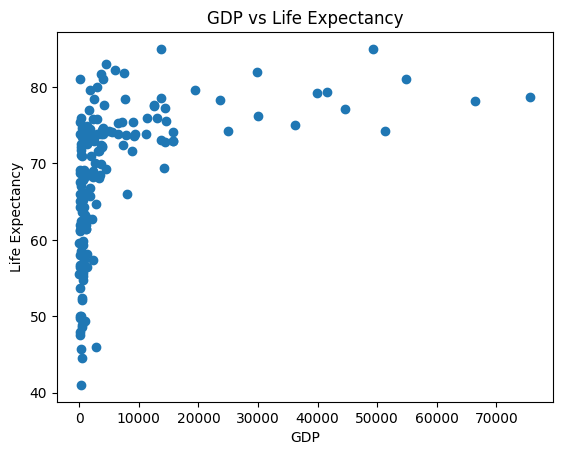

In [ ]:
from matplotlib import pyplot as plt
import numpy as np

# gather sample from dataset
sample_df = df.sample(n=200, random_state=11)

# clean sample and discard missing values
clean_df = sample_df[['GDP', 'Life expectancy ']].dropna()

#create df for GDP and Life Expectancy
gdp_df = clean_df['GDP']
life_expectancy_df = clean_df['Life expectancy ']

# plot scatter plot
plt.scatter(gdp_df, life_expectancy_df)
plt.xlabel("GDP")
plt.ylabel("Life Expectancy")
plt.title("GDP vs Life Expectancy")
plt.show()

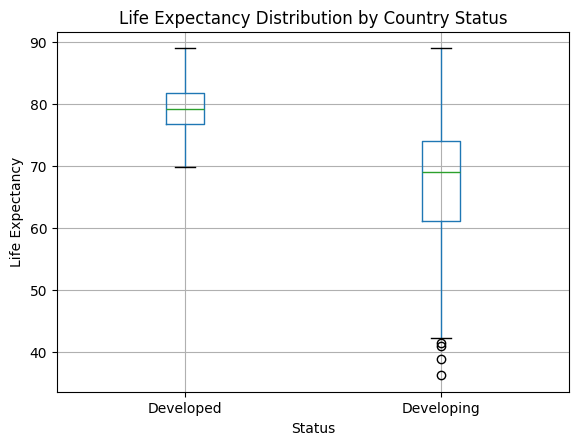

In [ ]:
df.boxplot(column="Life expectancy ", by="Status")

#create bar graphs for developing vs developed countries
plt.ylabel("Life Expectancy")
plt.title("Life Expectancy Distribution by Country Status")
plt.suptitle("")
plt.show()

Text(0.5, 1.0, 'Correlation Matrix of Life Expectancy Factors')

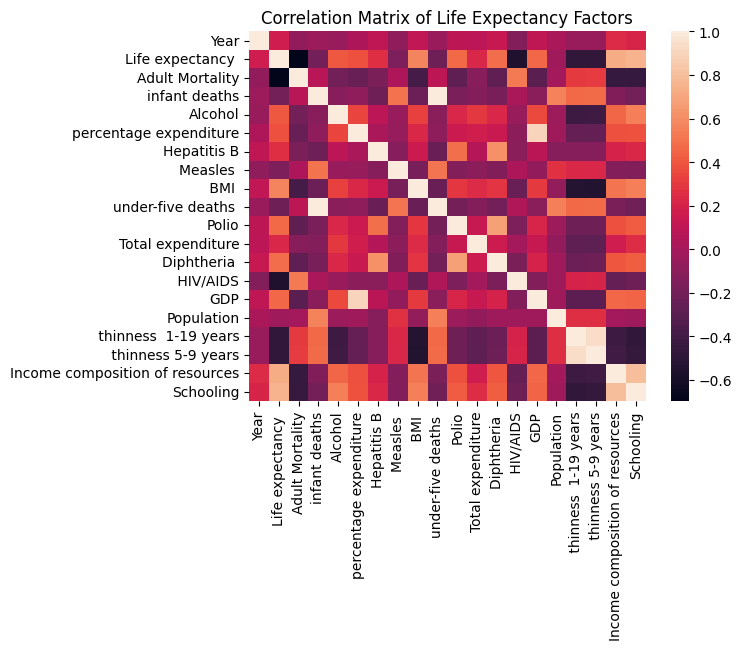

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

#create a heatmap for factors of life expectancy
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=False)
plt.title("Correlation Matrix of Life Expectancy Factors")

In [ ]:
import pandas as pd

# fix column names
df = df.dropna()
df.columns = df.columns.str.strip()

df["Income Group"] = pd.qcut(df["GDP"], 4,
                            labels=["Low", "Lower-Middle", "Upper-Middle", "High"])

df["Education Level"] = pd.cut(df["Schooling"],
                              bins=[0, 8, 12, 20],
                              labels=["Low", "Medium", "High"])

df["Health Efficiency"] = df["Life expectancy"] / df["GDP"]

df["GDP per Life Year"] = df["GDP"] / df["Life expectancy"]

df.to_csv("life_expectancy_cleaned.csv", index=False)